# ID 5841 Quantum Computing – Assignment 3 (Scaffold)
Department of Physics, IIT Madras  
Deutsch–Jozsa and Grover Algorithms  

This notebook provides **background** and **code templates** to help you attempt Assignment 3.  
It does **not** contain complete solutions; you must derive the key steps yourself.

---

## Prerequisites

Before starting, make sure you are comfortable with:
- Single- and multi-qubit gates (X, Z, H, CNOT, controlled-U).
- Oracle unitaries $U_f$ for Boolean functions.
- The Deutsch–Jozsa algorithm for $n$-bit functions promised to be constant or balanced.
- Grover’s search algorithm and the concept of an oracle that marks “solution” states.
- Basic Qiskit usage (constructing circuits, simulators, running jobs, reading histograms).
---

## Imports and basic setup


In [25]:
# Core Qiskit imports (adjust to your environment if needed)
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit.visualization import plot_histogram

# Aer / simulators
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise.errors import amplitude_damping_error, pauli_error

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# For numerical work
import numpy as np

---
# 1. Deutsch–Jozsa Algorithm on IBMQ (Simulators)

We consider the 3-bit Boolean function
$$f(x_0, x_1, x_2) = x_0 \oplus (x_1 x_2),$$
where $x_1 x_2$ denotes the AND of $x_1$ and $x_2$.

The DJ promise problem: given a function $f:\{0,1\}^n \to \{0,1\}$ which is guaranteed to be either constant or balanced, determine which case holds using a single query to the oracle $U_f$ in the quantum version.
---

## 1(i) Classical analysis of the function (pencil-and-paper section)

Goal:
- Enumerate all $2^3$ inputs $(x_0,x_1,x_2)$.
- Compute $f(x_0, x_1, x_2)$ for each input.
- Decide whether the function is constant or balanced.
- Count how many queries of a classical black-box you would need in the worst case.

**Do this analysis by hand or in separate notes.**  
Below is an *optional* code cell you may use to check your own derivation (do not simply rely on it to answer).

In [13]:
# OPTIONAL CHECK ONLY – you should derive the truth table yourself first.

def f_classical(x0, x1, x2):
    """
    Classical implementation of f(x0,x1,x2) = x0 XOR (x1 AND x2).
    Fill this only after you have derived the expression for yourself.
    """
    # TODO: Implement x0 XOR (x1 AND x2) as integers 0/1
    # return ...
    raise NotImplementedError("Fill in after doing the truth-table by hand.")

# Example of generating all inputs (you can uncomment after writing f_classical).

# for x0 in [0, 1]:
#     for x1 in [0, 1]:
#         for x2 in [0, 1]:
#             print(x0, x1, x2, "->", f_classical(x0, x1, x2))

In your written solution, clearly state:
- The full truth table.
- Whether $f$ is constant or balanced.
- The number of classical oracle queries you need in the worst case.

---

## 1(ii) Deutsch–Jozsa: Oracle and noiseless simulation

### The Deutsch–Jozsa circuit structure

For a 3-bit function $f$, the standard DJ circuit uses:
- $n = 3$ input qubits, initialised in $\lvert 0 \rangle^{\otimes 3}$.
- One ancilla/output qubit initialised in $\lvert 1 \rangle$.
- Apply Hadamards to all $n+1$ qubits.
- Apply the oracle $U_f$ that maps $\lvert x \rangle \lvert y \rangle \mapsto \lvert x \rangle \lvert y \oplus f(x)\rangle$.
- Apply Hadamards again to the first $n$ qubits.
- Measure the first $n$ qubits in the computational basis. 

Interpretation:
- If $f$ is constant, the outcome should be $\lvert 000 \rangle$ with probability 1 (ideal case).
- If $f$ is balanced, at least one input qubit outcome should be 1 with nonzero probability, and $\lvert 000 \rangle$ should have probability 0 in the ideal DJ setting. 

---

### 1(ii-a) Constructing the oracle $U_f$

You need to construct a quantum circuit that implements
$$U_f \lvert x_0 x_1 x_2 \rangle \lvert y \rangle = \lvert x_0 x_1 x_2 \rangle \lvert y \oplus f(x_0,x_1,x_2) \rangle.$$

Plan the gate decomposition:

- Step 1: Express $f(x_0,x_1,x_2)$ in terms of XOR and AND.
- Step 2: Identify which controlled operations you need to flip the output qubit depending on the inputs.
- Step 3: Translate this into a circuit that uses:
  - X gates to condition on 0 if needed,
  - multi-controlled X (Toffoli) for the AND part,
  - CNOT for the XOR part,
  - possible ancilla qubits if you choose to decompose multi-controlled gates.

You can encapsulate the oracle as a function returning a `QuantumCircuit` on 4 qubits (3 inputs + 1 output). The template below is **incomplete**; you must fill in the controlled operations.

In [14]:
def deutsch_jozsa_oracle_f():
    """
    Returns a QuantumCircuit implementing the oracle Uf for
    f(x0,x1,x2) = x0 XOR (x1 AND x2) on 4 qubits:
    q[0], q[1], q[2] are inputs; q[3] is the output/ancilla.
    """
    qc_oracle = QuantumCircuit(4, name="U_f")
    
    # TODO:
    # 1. Implement the AND of x1 and x2, and XOR it with x0 on the output qubit.
    # 2. Use controlled-X (CNOT/Toffoli) and X-gates as appropriate.
    # 3. Remember that Uf acts as |x>|y> -> |x>|y XOR f(x)>.
    # 4. Do not measure here.
    
    # Example pattern (NOT the actual solution):
    # qc_oracle.ccx(1, 2, 3)   # placeholder: controlled-controlled-X
    # qc_oracle.cx(0, 3)       # placeholder: XOR with x0
    
    return qc_oracle

You should verify by reasoning (or optionally by a small state-vector simulation) that $U_f$ acts correctly on all basis states. 

---

### 1(ii-b) Full Deutsch–Jozsa circuit (noiseless)

Use the oracle to build the full DJ circuit with 4 qubits (3 input + 1 ancilla). 

Steps:
1. Initialise $\lvert 0 0 0 1 \rangle$.
2. Apply H on all 4 qubits.
3. Apply your `deutsch_jozsa_oracle_f` as a gate.
4. Apply H on the first 3 qubits only.
5. Measure the first 3 qubits into classical bits.
6. Run the circuit on a noiseless simulator (e.g., `AerSimulator()` with default settings), and plot the histogram of results.

Use the template below and fill in the missing pieces.

In [23]:
# Build Deutsch–Jozsa circuit for f

# Quantum and classical registers
dj_qc = QuantumCircuit(4, 3)

# Step 1: Initialise |0001> (output qubit in |1>)
# By default qubits start in |0>, so apply X to qubit 3.
# TODO: apply X to output qubit.

# Step 2: Apply Hadamards to all qubits
# TODO: H on all 4 qubits.

# Step 3: Attach oracle Uf
oracle = deutsch_jozsa_oracle_f()
dj_qc.append(oracle.to_gate(), [0, 1, 2, 3])

# Step 4: Apply Hadamards to the first 3 qubits
# TODO: H on qubits 0,1,2.

# Step 5: Measure the first 3 qubits
# TODO: measure qubits 0,1,2 into classical bits 0,1,2.
# Remember Qiskit uses little-endian ordering by default.

print(dj_qc.draw())

# Simulate
noiseless_sim = AerSimulator()
dj_qc_sim = transpile(dj_qc, noiseless_sim)
result = noiseless_sim.run(dj_qc_sim, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

     ┌──────┐
q_0: ┤0     ├
     │      │
q_1: ┤1     ├
     │  U_f │
q_2: ┤2     ├
     │      │
q_3: ┤3     ├
     └──────┘
c: 3/════════
             


QiskitError: 'No counts for experiment "0"'

From the histogram, determine whether the measurement outcome is consistent with $f$ being constant or balanced, in the **ideal noiseless** case. 

---

## 1(iii) Deutsch–Jozsa with noise

Now add a noise model to study the effect of realistic errors.

You can choose one of:
- Bit-flip noise
- Phase-flip noise
- Amplitude damping
- (Or a small coherent error if you construct such a channel) 

### 1(iii-a) Define a noise model

The idea is to:
- Create a `NoiseModel()`.
- Add single-qubit errors to some gates (e.g., `"x"`, `"h"`, or `"cx"`).
- Use this noise model in `AerSimulator(noise_model=...)`.

**Template:**

In [ ]:
# Example: constructing a simple noise model (you must choose parameters and gates)

# If amplitude_damping_error is missing, install qiskit-aer
# %pip install qiskit-aer

noise_model = NoiseModel()

# Choose error type and parameter (you should pick and justify gamma or p).
# Example placeholders (NOT final): 
p_bitflip = 0.01
p_phaseflip = 0.01
gamma_amp = 0.02

# Define some error channels
bitflip_err = pauli_error([('X', p_bitflip), ('I', 1 - p_bitflip)])
phaseflip_err = pauli_error([('Z', p_phaseflip), ('I', 1 - p_phaseflip)])
ampdamp_err = amplitude_damping_error(gamma_amp)

# TODO: Decide which error(s) to use and on which gates.
# For example:
# noise_model.add_all_qubit_quantum_error(bitflip_err, ['x'])
# noise_model.add_all_qubit_quantum_error(phaseflip_err, ['h'])

# Build a noisy simulator
noisy_sim = AerSimulator(noise_model=noise_model)

pm = generate_preset_pass_manager(backend=noisy_sim, optimization_level=3)

### 1(iii-b) Run Deutsch–Jozsa with noise

Use the same `dj_qc` circuit as before, but transpile and run it on `noisy_sim`. Then compare the output distribution with the noiseless case. 

In [ ]:
# Transpile and run on noisy simulator
dj_qc_noisy = transpile(dj_qc, noisy_sim)
result_noisy = noisy_sim.run(dj_qc_noisy, shots=1024).result()
counts_noisy = result_noisy.get_counts()

circuit_hardware = pm.run(dj_qc_noisy)

sampler = Sampler(mode=noisy_sim)
job = sampler.run([circuit_hardware], shots=1024)
counts = job.result()[0].data.meas.get_counts()

plot_histogram([counts, counts_noisy], title="Deutsch–Jozsa: noiseless vs noisy", legend=["Noiseless", "Noisy"])

QiskitError: 'No counts for experiment "0"'

In your write-up, comment on:
- How the probability of the “ideal” output string changes.
- How this affects your ability to distinguish constant vs balanced in the presence of noise. 

---

# 2. Grover Search for a 3-SAT Problem

We consider the 3-SAT Boolean function of three variables $x_1, x_2, x_3 \in \{0,1\}$: 

\begin{aligned}
f(x_1,x_2,x_3) &= (x_1 \lor x_2 \lor x_3) 
\land (\lnot x_1 \lor x_2 \lor x_3)
\land (\lnot x_1 \lor \lnot x_2 \lor x_3) \\
&\quad \land (\lnot x_1 \lor \lnot x_2 \lor \lnot x_3)
\land (x_1 \lor x_2 \lor \lnot x_3)
\land (\lnot x_1 \lor x_2 \lor \lnot x_3).
\end{aligned}


Your tasks:

1. Derive the truth table and show that there are exactly two satisfying assignments (two input strings with $f=1$).
2. Construct a quantum oracle that “marks” these satisfying strings (Grover oracle).
3. Use Grover’s algorithm to find the solutions.
4. Compare ideal and noisy simulations on IBMQ-style simulators.

---

## 2(i) Truth table and satisfying assignments (by hand)

First, do the following on paper:

- Enumerate all 8 possible triples $(x_1,x_2,x_3)$.
- For each input, evaluate each clause and then the overall \$land$ of the clauses.
- Identify which assignments make **all** clauses true.
- Verify that exactly two assignments satisfy the formula. 

You may optionally use a Python helper **after** you have done this manually, to check your truth table.

In [7]:
# OPTIONAL CHECK ONLY – fill only after you have the truth table yourself.

def f_3sat(x1, x2, x3):
    """
    Boolean function for the given 3-SAT formula.
    Implement this only after you have derived the expression by hand.
    Return 0 or 1.
    """
    # TODO: implement formula using Python booleans or ints
    # Example skeleton:
    # clause1 = ...
    # ...
    # return int(clause1 and clause2 and ...)
    raise NotImplementedError("Fill in after deriving clauses by hand.")

# Example enumeration:
# for x1 in [0, 1]:
#     for x2 in [0, 1]:
#         for x3 in [0, 1]:
#             print(x1, x2, x3, "->", f_3sat(x1, x2, x3))

In your written solution, list explicitly the two satisfying assignments you found.

---

## 2(ii) Constructing the Grover oracle for this 3-SAT

For Grover’s algorithm, we need an oracle $U_f$ that acts as:

$$U_f \lvert x \rangle = (-1)^{f(x)} \lvert x \rangle,$$
i.e., it flips the phase of the satisfying states and leaves the others unchanged.

There are two common strategies here:

1. **Direct marking**: If you know the satisfying bit strings explicitly (from part (i)), you can build an oracle that applies a phase flip only on those computational basis states, using X gates and multi-controlled Z or X gates. 
2. **Clause-based oracle** (more literal 3-SAT encoding): Introduce ancilla qubits to represent clause evaluations, then map the satisfiability to a flag qubit and apply a phase flip on that flag. This more closely mirrors the 3-SAT structure but is more circuit-heavy. 

In this assignment, it is usually acceptable to choose strategy (1) once you have the satisfying strings, as long as you explain how it corresponds to the 3-SAT oracle. 

### Template for a marking oracle with known solutions

Suppose you know that the two satisfying inputs are $s^{(1)}$ and $s^{(2)}$, each a 3-bit string (you will fill these in). Conceptually:

- For each satisfying pattern s:
  - Use X gates to map $\lvert s \rangle$ to $\lvert 111 \rangle$.
  - Apply a multi-controlled Z (or X + phase) that adds a phase of -1 only to $\lvert 111 \rangle$.
  - Undo the X gates. 

You can combine both marked states into a single oracle by doing this twice in sequence.

**Template (does not implement any specific pattern yet):**

In [8]:
def grover_oracle_3sat():
    """
    Grover oracle for the given 3-SAT problem on 3 qubits (no ancilla shown here).
    It should multiply satisfying basis states by -1 in phase.
    You need to fill in the specific patterns and gate sequence.
    """
    qc = QuantumCircuit(3, name="GroverOracle")

    # TODO:
    # 1. Insert X gates to map your first satisfying assignment to |111>.
    # 2. Apply a multi-controlled Z (can be implemented via H + CCX + H on the target).
    # 3. Undo the X gates.
    # 4. Repeat for the second satisfying assignment.
    #
    # Hint: Qiskit pattern for cc-phase via X:
    #   qc.h(2)
    #   qc.ccx(0, 1, 2)
    #   qc.h(2)

    return qc

You may also implement a more explicit clause-based oracle if you prefer, possibly with additional ancilla qubits; if you do so, make sure to document the mapping from clauses to qubits.

---

## 2(iii) Grover search to find the satisfying assignments

### Grover circuit structure for 3 qubits and 2 solutions

The standard Grover iteration $G$ consists of:
1. Oracle $U_f$ (phase flip on solutions).
2. Diffuser (inversion about the mean) on the search register.

The diffuser for $n$ qubits can be implemented as:
- Apply H to all qubits.
- Apply X to all qubits.
- Apply multi-controlled Z to flip $\lvert 00\ldots 0 \rangle$.
- Apply X to all qubits.
- Apply H to all qubits again. 
**Template for diffuser on 3 qubits:**

In [9]:
# Template for diffuser on 3 qubits
def diffuser_3qubits():
    """
    3-qubit Grover diffuser gate.
    """
    qc = QuantumCircuit(3, name="Diffuser")

    # Step 1: H on all qubits
    qc.h([0, 1, 2])

    # Step 2: X on all qubits
    qc.x([0, 1, 2])

    # Step 3: multi-controlled Z (phase flip on |000>)
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)

    # Step 4: X on all qubits
    qc.x([0, 1, 2])

    # Step 5: H on all qubits
    qc.h([0, 1, 2])

    return qc

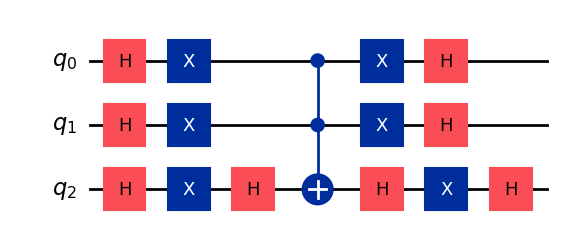

In [11]:
diffuser_3qubits().draw('mpl')

### Number of Grover iterations

For $N = 2^n$ possible states and $M$ marked solutions, the optimal number of Grover iterations is approximately

$$r \approx \left\lfloor \frac{\pi}{4} \sqrt{\frac{N}{M}} \right\rfloor.$$

Here, $n=3$, $N=8$ and you have shown that $M=2$.  
Compute $r$ explicitly and use this value in your circuit. 

---

### 2(iii-a) Build and run Grover circuit (noiseless)

Steps:

1. Prepare the 3-qubit search register in equal superposition $\frac{1}{\sqrt{8}} \sum_x \lvert x \rangle$ using H gates.
2. Apply Grover iteration $G = D \circ U_f$ exactly $r$ times, where $U_f$ is your `grover_oracle_3sat()` and $D$ is `diffuser_3qubits()`.
3. Measure the 3 qubits and inspect the histogram.
4. Check that the two satisfying assignments occur with high probability.

**Template:**

In [22]:
# Build Grover search circuit for the 3-SAT problem

grover_qc = QuantumCircuit(3, 3)

# Step 1: initialise equal superposition over 3 qubits
# TODO: apply H on all three qubits.
# grover_qc.h([0,1,2])

# Define oracle and diffuser
oracle = grover_oracle_3sat()
diff = diffuser_3qubits()

# Number of Grover iterations (compute r by hand and then set it here)
r = None  # TODO: replace with integer number of iterations

# Step 2: apply r Grover iterations
for _ in range(r):
    grover_qc.append(oracle.to_gate(), [0, 1, 2])
    grover_qc.append(diff.to_gate(), [0, 1, 2])

# Step 3: measure
grover_qc.measure([0, 1, 2], [0, 1, 2])

print(grover_qc.draw())

# Run on noiseless simulator
grover_sim = AerSimulator()
grover_qc_sim = transpile(grover_qc, grover_sim)
result_grover = grover_sim.run(grover_qc_sim, shots=1024).result()
counts_grover = result_grover.get_counts()

plot_histogram(counts_grover, title="Grover search for 3-SAT (noiseless)")

TypeError: 'NoneType' object cannot be interpreted as an integer

From the histogram, identify which bit strings appear with highest probability and verify they match the satisfying assignments from part 2(i).

---

## 2(iv) Grover search with noise (IBM-style noisy simulators)

As in part 1(iii), introduce a noise model and run the Grover circuit with noise.

You may:
- Reuse the same `NoiseModel` as before, or
- Design a different noise model targeting specific gates (e.g., errors on `cx` only).

### 2(iv-a) Noisy Grover simulation

In [21]:
# Reuse or redefine a noise model for Grover
# (Option 1: reuse noise_model; Option 2: create a new one.)

# Example: reuse 'noise_model' from above (ensure it is defined).
noisy_grover_sim = AerSimulator(noise_model=noise_model)

grover_qc_noisy = transpile(grover_qc, noisy_grover_sim)
result_grover_noisy = noisy_grover_sim.run(grover_qc_noisy, shots=1024).result()
counts_grover_noisy = result_grover_noisy.get_counts()

plot_histogram(
    [counts_grover, counts_grover_noisy],
    title="Grover 3-SAT: noiseless vs noisy",
    legend=["Noiseless", "Noisy"]
)

QiskitError: 'No counts for experiment "0"'